# DeltaNet：delta rule —— 纠错式状态更新（快速权重）

> linear attention 的状态**只加不减**（`Sₜ = Sₜ₋₁ + kₜvₜᵀ`），键冲突时旧值残留、混叠。**DeltaNet**
> 用 **delta rule**：写入前先用 kₜ 查询旧状态、算预测误差，只写入误差 —— 等价于"先擦掉 kₜ 方向的旧
> 记忆、再写新值"。本章把它的数学讲透：从最小二乘/快速权重的推导、定向擦写、WY 表示如何块内并行，
> 再逐段读**完整解耦自 fla** 的真实 chunk-parallel kernel。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "11-deltanet"))

from common.nbtools import setup_cjk, show_code   # 中文字体 + 暗色代码
setup_cjk()
from deltanet import delta_rule_recurrent, delta_rule_chunked

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 把状态矩阵看作一个"在线学习的回归器"

把状态 $S\in\mathbb{R}^{d_k\times d_v}$ 看作一个线性映射：给 key 输出 value 预测 $\hat v = S^\top k$。
"写入 $(k_t,v_t)$"应让 $S$ 在 $k_t$ 处输出 $v_t$。

- **linear attention**：$S_t = S_{t-1} + k_t v_t^\top$ —— 直接叠加，不管 $S$ 在 $k_t$ 处原来输出什么；
- **delta rule**：把它当成最小化 $\tfrac12\|S^\top k_t - v_t\|^2$ 的一步在线梯度下降，

$$\hat v_t = S_{t-1}^\top k_t,\qquad S_t = S_{t-1} + \beta_t\, k_t (v_t - \hat v_t)^\top.$$

这就是 **Widrow-Hoff / LMS** 规则。下面用一个**键冲突**的小实验，直接看两者的差别。

In [2]:
# 键冲突实验：同一个 key 先后写入两个不同 value，看 query 读出"记住"哪个
torch.manual_seed(0)
D = 32
k1 = F.normalize(torch.randn(D, device="cuda"), dim=-1)          # 固定 key
vA, vB = torch.randn(D, device="cuda"), torch.randn(D, device="cuda")

# 序列：t0 写(k1,vA) → t1 写(k1,vB，覆盖) → 每步都用 k1 query
sk = torch.stack([k1, k1])[None, None]                           # (1,1,2,D)
sv = torch.stack([vA, vB])[None, None]
sq = torch.stack([k1, k1])[None, None]
beta = torch.ones(1, 1, 2, device="cuda")

o_delta = delta_rule_recurrent(sq, sk, sv, beta, l2norm=False, scale=1.0)

# linear attention（只加不减）的逐步 recurrent
S = torch.zeros(D, D, device="cuda"); o_lin = []
for t in range(2):
    S = S + torch.outer(sk[0, 0, t], sv[0, 0, t])
    o_lin.append(sq[0, 0, t] @ S)
o_lin = torch.stack(o_lin)

# t1（第二次写 vB 之后）用 k1 读出，理想应 = vB（最新）
print("写入 vA、再用同 key 覆盖写 vB 后，用该 key 读出：")
print(f"  delta rule  : 距 vB={ (o_delta[0,0,1]-vB).norm():.3f}  距 vA={ (o_delta[0,0,1]-vA).norm():.3f}  → 记住最新 vB ✓")
print(f"  linear attn : 距 vB={ (o_lin[1]-vB).norm():.3f}  距 vA={ (o_lin[1]-vA).norm():.3f}  → vA+vB 混叠 ✗")
print("\ndelta rule 写 vB 前先擦掉 k1 方向的旧记忆(vA)，所以读出干净的 vB；linear attention 把两次写入叠加。")

写入 vA、再用同 key 覆盖写 vB 后，用该 key 读出：
  delta rule  : 距 vB=0.000  距 vA=7.467  → 记住最新 vB ✓
  linear attn : 距 vB=4.726  距 vA=5.913  → vA+vB 混叠 ✗

delta rule 写 vB 前先擦掉 k1 方向的旧记忆(vA)，所以读出干净的 vB；linear attention 把两次写入叠加。


## 2. delta rule = 定向擦写

把更新式展开，能看清它在"擦"什么：

$$S_t = S_{t-1} + \beta_t k_t v_t^\top - \beta_t k_t (S_{t-1}^\top k_t)^\top
     = S_{t-1}\underbrace{(I - \beta_t k_t k_t^\top)}_{\text{沿 }k_t\text{ 收缩}} + \underbrace{\beta_t v_t k_t^\top}_{\text{写入新值}}.$$

$(I-\beta_t k_t k_t^\top)$ 是沿 $k_t$ 方向的收缩算子：把 $S$ 中与 $k_t$ 对齐的分量按 $\beta_t$ 缩掉。
所以不是 GLA 那种"所有维度按门控衰减"，而是**只在当前 key 方向定向擦写**。$\beta_t$ 控制力度：

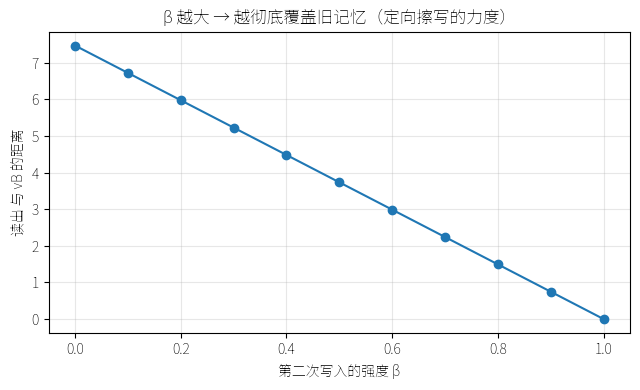

β=0：完全没写第二次（读出≈vA，距 vB 最大）；β=1：完全覆盖（读出=vB，距离≈0）。


In [3]:
# β 的作用：在键冲突实验里扫 β，看"覆盖"程度（β=1 完全覆盖旧值，β=0 不写）
betas = torch.linspace(0, 1, 11)
dist_to_vB = []
for b in betas:
    bb = torch.tensor([[[1.0, b]]], device="cuda")   # 第一次写满，第二次写强度 b
    od = delta_rule_recurrent(sq, sk, sv, bb, l2norm=False, scale=1.0)
    dist_to_vB.append((od[0, 0, 1] - vB).norm().item())

plt.figure(figsize=(6.5, 4))
plt.plot(betas.numpy(), dist_to_vB, "o-")
plt.xlabel("第二次写入的强度 β"); plt.ylabel("读出 与 vB 的距离")
plt.title("β 越大 → 越彻底覆盖旧记忆（定向擦写的力度）"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("β=0：完全没写第二次（读出≈vA，距 vB 最大）；β=1：完全覆盖（读出=vB，距离≈0）。")

## 3. WY 表示：把"逐步擦写"变成块内可并行

recurrent 严格串行（$S_t$ 依赖 $S_{t-1}$）。chunk 内连续 $t$ 步是矩阵连乘 $\prod_t(I-\beta_t k_t k_t^\top)$。
**WY 表示**证明它等价于一个**下三角线性系统的逆**：

$$T = \big(I - \operatorname{tril}(\operatorname{diag}(\beta)KK^\top,\,-1)\big)^{-1},\qquad
  u = T(\beta\!\odot\!V),\quad w = T(\beta\!\odot\!K).$$

有了 $T$，块内一次算出、块间只传一个状态 $S$ 递归。下面验证 recurrent ≡ chunked，并看 $T$ 的下三角结构。

recurrent ≡ chunked(WY 表示)  max diff: 1.6391277313232422e-07


/tmp/ipykernel_2333541/2261646900.py:16: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Noto Sans SC.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_2333541/2261646900.py:16: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Noto Sans SC.
  plt.tight_layout(); plt.show()
/home/robomaster/anaconda3/envs/py312_numba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Noto Sans SC.
  fig.canvas.print_figure(bytes_io, **kw)
/home/robomaster/anaconda3/envs/py312_numba/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Noto Sans SC.
  fig.canvas.print_figure(bytes_io, **kw)


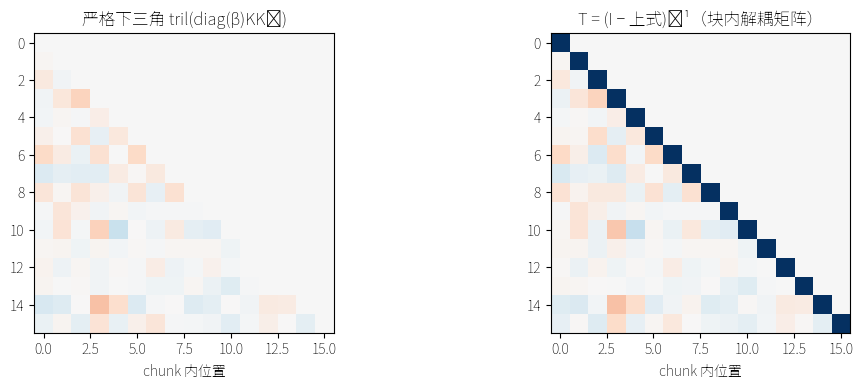

T 是下三角：第 i 行把前 i 步的 delta 依赖一次性解开，于是块内能并行算 u=Tv、w=Tk。


In [4]:
q, k, v = (torch.randn(2, 4, 256, 64, device="cuda") for _ in range(3))
beta = torch.rand(2, 4, 256, device="cuda")
rec = delta_rule_recurrent(q, k, v, beta)
chk = delta_rule_chunked(q, k, v, beta, chunk_size=64)
print("recurrent ≡ chunked(WY 表示)  max diff:", (rec - chk).abs().max().item())

# 可视化一个 chunk 的 T = (I - tril(βKKᵀ))⁻¹
C = 16
kk = F.normalize(torch.randn(C, 32), dim=-1); bb = torch.rand(C)
M = (bb[:, None] * (kk @ kk.t())).tril(-1)
T = torch.linalg.solve_triangular(torch.eye(C) - M, torch.eye(C), upper=False)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(M.numpy(), cmap="RdBu", vmin=-1, vmax=1); ax[0].set_title("严格下三角 tril(diag(β)KKᵀ)")
ax[1].imshow(T.numpy(), cmap="RdBu", vmin=-1, vmax=1); ax[1].set_title("T = (I − 上式)⁻¹（块内解耦矩阵）")
for a in ax: a.set_xlabel("chunk 内位置")
plt.tight_layout(); plt.show()
print("T 是下三角：第 i 行把前 i 步的 delta 依赖一次性解开，于是块内能并行算 u=Tv、w=Tk。")

## 4. 深度优化版：完整解耦自 fla 的 chunk-parallel kernel

DeltaNet 的 fla kernel 由 **8 个 triton 文件**组成（WY 表示 `_fla_wy_fast` + 解三角 `_fla_solve_tril`、
块间状态 `_fla_chunk_delta_h`、输出 `_fla_chunk_o`、L2norm 等）。它比 GLA 耦合深，还通过 `backends.dispatch`
静态引入多卡 CP / TileLang 后端 / full attention（朴素闭包 ~27 文件、不收敛）。

**完整解耦的关键**：那些后端全经 `@dispatch('common')` 引入，本仓库用 **no-op dispatch**（直接返回被
装饰的 triton 实现，见 `_fla_compat.py`）替换它 → CP/TileLang 全部不进闭包，收敛到 8 个 triton 文件、
脱离 fla 独立运行（计算逻辑一字未改）。下面展示主 kernel 源码（暗色，适配深色编辑器）：

In [5]:
show_code(str(ROOT / "11-deltanet" / "_fla_delta_chunk.py"))

### 逐段读懂（chunk-parallel + WY）

1. **L2 归一化 + 缩放**：`use_qk_l2norm_in_kernel` 在 kernel 内对 q/k 做 L2 归一化（delta rule 常配），q 乘 1/√d。
2. **WY 表示**（`_fla_wy_fast`）：算 `T=(I−tril(βKKᵀ))⁻¹`（用 `_fla_solve_tril` 批量解下三角）、`u=Tv`、`w=Tk_β`。
3. **块间递归状态**（`_fla_chunk_delta_h`）：沿 chunk 维前向/反向传状态 H —— 把"逐步擦写"的跨块依赖收成 O(块数) 递归。
4. **合并**（`_fla_chunk_o`）：`o = q·S(块间) + tril(qkᵀ)·(u − w·S)(块内)`。
5. **变长 cu_seqlens**：`prepare_chunk_indices`（本仓库从 fla 拷的纯 torch 索引）让 packed 多序列按序列分块。

WY 表示的核心源码：

In [6]:
show_code(str(ROOT / "11-deltanet" / "_fla_wy_fast.py"))

### 验证：解耦没改任何计算

定长 + 变长（cu_seqlens），本地解耦 kernel 与 fla 原版近 bitwise 一致；并与简要版 recurrent 对齐。

In [7]:
from _fla_delta_chunk import chunk_delta_rule as local
B, T, H, D = 2, 512, 4, 64
g = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=g)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=g)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=g)
beta = torch.rand(B, T, H, device="cuda", dtype=torch.bfloat16, generator=g)

ol, _ = local(q, k, v, beta, use_qk_l2norm_in_kernel=True)
try:
    from fla.ops.delta_rule import chunk_delta_rule as flad
    of, _ = flad(q, k, v, beta, use_qk_l2norm_in_kernel=True)
    print("① 定长：本地解耦 vs fla 原版   max diff:", (ol.float() - of.float()).abs().max().item())
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp = (x.reshape(1, B * T, H, D) for x in (q, k, v)); bp = beta.reshape(1, B * T, H)
    o2, _ = local(qp, kp, vp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    f2, _ = flad(qp, kp, vp, bp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    print("② 变长(cu_seqlens)：本地 vs fla    max diff:", (o2.float() - f2.float()).abs().max().item())
except ImportError:
    print("（未装 fla，跳过原版对照）")

o_rec = delta_rule_recurrent(*(x.transpose(1, 2) for x in (q, k, v)), beta.transpose(1, 2), l2norm=True).transpose(1, 2)
print("③ 本地 chunk vs 简要版 recurrent   max diff:", (ol.float() - o_rec.float()).abs().max().item())
print("→ 完整解耦（含变长索引）没改任何计算：与 fla bitwise 一致、与 recurrent ground truth 对齐。")

① 定长：本地解耦 vs fla 原版   max diff: 0.0


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.0
③ 本地 chunk vs 简要版 recurrent   max diff: 0.00239776074886322
→ 完整解耦（含变长索引）没改任何计算：与 fla bitwise 一致、与 recurrent ground truth 对齐。


## 5. 收尾

- **delta rule** 把状态当"在线回归器"：写入前先查询旧状态、算误差，**定向擦写** $S(I-\beta kk^\top)+\beta vk^\top$
  —— 比 GLA 的逐维衰减更接近"在线学习/检索"，键冲突时不混叠（§1 实验）。
- **WY 表示**把块内逐步擦写重排成 $T=(I-\operatorname{tril}(\beta KK^\top))^{-1}$ 的一次求逆 + 块间递归，
  让它能 chunk-parallel 训练（§3）。
- **深度优化版**完整解耦自 fla（8 个 triton 文件），用 no-op dispatch 收敛闭包、脱离 fla，与原版 bitwise 一致。

> 下一站 → 12-kda（Kimi Delta Attention）：在 delta rule 上叠加**细粒度门控**（gated delta + per-channel
> decay），Kimi Linear 的核心。